**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Alejandro Rendón De Jesús
*   MATRÍCULA: A01664589


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [2]:
weather_df = pd.read_csv('cleaned_weather.csv')

In [3]:
# 1.1
Nrows, Ncols = weather_df.shape
print('Nrows:', Nrows, ', Ncols:', Ncols)

Nrows: 52696 , Ncols: 13


In [4]:
# 1.2
columns = weather_df.columns.tolist()
print(columns)

['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv', 'wd', 'rain', 'raining']


In [5]:
# 1.3
newColumnsStr = r"medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia"
newColumns = newColumnsStr.split(', ')

weather_df.columns = newColumns
print(newColumns)

['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']


In [6]:
# 1.4 (primeros 5 registros)
weather_df.iloc[:5]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [7]:
# 1.5 (últimos 5 registros)
weather_df.iloc[-5:]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [8]:
# 1.6
nan_values = weather_df.isna().sum().values.sum()
if nan_values == 0:
    print('No hay valores faltantes')
else:
    print('Valores faltantes:', nan_values)

No hay valores faltantes


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [9]:
# 2.0 Tipos de datos originales
weather_df.dtypes

medicion                object
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia          int64
dtype: object

> **Respuesta:** `medicion` es de tipo `object` (texto), `duracion_lluvia` es `int64` y el resto de los indicadores son `float64`. Por eso es necesario convertir `medicion` a `datetime` para poder operar con fechas y horas.

In [10]:
# 2.1
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format = "%d/%m/%y %H:%M", errors = 'coerce')

# 2.2
weather_df['medicion_fecha'] = weather_df['medicion'].dt.date
weather_df['medicion_hora'] = weather_df['medicion'].dt.time

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [11]:
# 3.0 Valores únicos por columna
print('Número de registros:', len(weather_df))
weather_df.nunique()

Número de registros: 52696


medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
medicion_fecha           367
medicion_hora            144
dtype: int64

In [12]:
# 3.1
dupDate = weather_df['medicion'].value_counts().reset_index().sort_values('count', ascending = False).iloc[0, 0]
print('Fecha duplicada:', dupDate)

Fecha duplicada: 2020-05-12 06:00:00


In [13]:
#3.2
dfAux = weather_df[weather_df['medicion'] == dupDate]

if dfAux.iloc[0].tolist() == dfAux.iloc[1].tolist():
    weather_df = weather_df.drop_duplicates()

> **Respuesta:** la fecha duplicada es **2020-05-12 06:00:00**. Los dos registros con esa fecha tienen exactamente los mismos valores en todas las columnas, así que se eliminó uno de ellos con `drop_duplicates()`: el dataframe pasa de 52,696 a **52,695 registros**, y ahora cada `medicion` es única.

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [14]:
# 4.0 Valores únicos por columna (sin el registro duplicado)
print('Número de registros:', len(weather_df))
weather_df.nunique()

Número de registros: 52695


medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
medicion_fecha           367
medicion_hora            144
dtype: int64

In [15]:
# 4.1
unique_times = weather_df['medicion_hora'].unique()
unique_times_dt = pd.to_datetime(unique_times.astype(str), format = '%H:%M:%S')
period = ((unique_times_dt[1:] - unique_times_dt[:-1]).seconds // 60).unique()[0]

print('Son mediciones periódicas:', f'{period} minutos')

Son mediciones periódicas: 10 minutos


> **Respuesta:** hay **144 horas diferentes** porque la estación registra una medición **cada 10 minutos**. En una hora hay 60 / 10 = 6 mediciones, y en un día 24 × 6 = **144**. Es decir, cada día se repite el mismo conjunto de 144 horas (00:00, 00:10, …, 23:50).

In [16]:
# 4.2
periods = (weather_df['medicion'].diff().dt.seconds // 60).values
outPeriodsIndex = (~pd.isna(periods)) & (periods != period)
outIndex = np.where(outPeriodsIndex == True)[0][0]
searchIndex = [outIndex + i for i in range(-1, 1)]

gapBetweenDates = weather_df[[True if i in searchIndex else False for i in range(len(weather_df))]]

missingSamples = (
    gapBetweenDates.iloc[1, 0] -
    gapBetweenDates.iloc[0, 0]
).seconds // (600) - 1

missingDates = [
    (gapBetweenDates.iloc[0, 0] + datetime.timedelta(seconds = 600 * i)).strftime("%Y-%m-%d %H:%M:%S")
    for i in range(1, missingSamples + 1)
]

print('Número de muestras faltantes:', missingSamples)
for i, date_ in enumerate(missingDates, start = 1):
  print(f'Fecha faltante {i}:', date_)

Número de muestras faltantes: 9
Fecha faltante 1: 2020-05-29 09:40:00
Fecha faltante 2: 2020-05-29 09:50:00
Fecha faltante 3: 2020-05-29 10:00:00
Fecha faltante 4: 2020-05-29 10:10:00
Fecha faltante 5: 2020-05-29 10:20:00
Fecha faltante 6: 2020-05-29 10:30:00
Fecha faltante 7: 2020-05-29 10:40:00
Fecha faltante 8: 2020-05-29 10:50:00
Fecha faltante 9: 2020-05-29 11:00:00


> **Respuesta:** si no faltara nada, las 367 fechas × 144 horas darían 52,848 combinaciones, pero solo hay 52,695 mediciones. Parte de la diferencia es normal: el archivo empieza el 01/01/2020 a las 00:10 (falta 00:00) y termina el 01/01/2021 a las 00:00 (solo un registro de 2021). Al revisar los intervalos entre mediciones consecutivas, solo hay **un salto distinto de 10 minutos**, de 1 h 40 min, el **29 de mayo de 2020**. Faltan **9 mediciones**, de las **09:40 a las 11:00**. Por eso ese día tiene 135 registros en vez de 144.

In [17]:
# 4.3
weather_df = weather_df[weather_df['medicion'].dt.year == 2020].drop(columns = 'medicion')
weather_df.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,medicion_fecha,medicion_hora
0,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [18]:
# 5.1
aggDict = {
    col: 'max'
    for col in weather_df.columns
    if not 'medicion' in col
}

indicadores_diarios = (
    weather_df.groupby('medicion_fecha')
    .agg(aggDict)
    .reset_index()
    .sort_values('medicion_fecha', ascending = False)
)

maxPrecDate = indicadores_diarios.loc[indicadores_diarios['precipitacion_total'] == indicadores_diarios['precipitacion_total'].max(), 'medicion_fecha'].values[0].strftime('%Y-%m-%d')
print('Máxima precipitación:', indicadores_diarios['precipitacion_total'].max(), 'mm')
print('Fecha con máxima precipitación:', maxPrecDate)

Máxima precipitación: 11.2 mm
Fecha con máxima precipitación: 2020-06-16


> **Respuesta:** la máxima precipitación fue de **11.2 mm** y ocurrió el **16 de junio de 2020**.

In [19]:
# 5.2
indicadores_diarios.sort_values('velocidad_viento', ascending = False)[['medicion_fecha', 'velocidad_viento']].iloc[:3]

,medicion_fecha,velocidad_viento
40,2020-02-10,13.77
46,2020-02-16,13.00
39,2020-02-09,12.52


> **Respuesta:** los tres días con las velocidades de viento más altas fueron el **10 de febrero** (13.77 m/s), el **16 de febrero** (13.00 m/s) y el **9 de febrero de 2020** (12.52 m/s). Los tres caen en febrero, lo que apunta a un mismo episodio de tormenta.

In [20]:
# 5.3
dias_calidos_humedos = indicadores_diarios.loc[
    (indicadores_diarios['humedad_relativa'] > 90) &
    (indicadores_diarios['temperatura_celsius'] > 30),
    ['medicion_fecha', 'humedad_relativa', 'temperatura_celsius']
].sort_values('medicion_fecha', ascending = False)

print('Días con humedad > 90% y temperatura > 30 °C:', len(dias_calidos_humedos))
dias_calidos_humedos

Días con humedad > 90% y temperatura > 30 °C: 5


,medicion_fecha,humedad_relativa,temperatura_celsius
258,2020-09-15,99.9,30.16
233,2020-08-21,94.7,34.56
232,2020-08-20,97.1,30.38
224,2020-08-12,94.4,32.26
223,2020-08-11,93.8,31.42


> **Respuesta:** **5 días** rebasaron a la vez el 90% de humedad relativa y los 30 °C: el 11, 12, 20 y 21 de agosto y el 15 de septiembre de 2020.
>
> *Nota:* la humedad está expresada en porcentaje (0–100), por lo que el umbral debe ser `90` y no `0.9`.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [21]:
descID = indicadores_diarios.describe()
descID

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


In [22]:
# 6.1
std = descID.loc[
    descID.index == 'std',
    'concentracion_vapor'
].values[0]

print('Desviación estándar:', round(std, 2))

Desviación estándar: 4.57


> **Respuesta:** la desviación estándar de la concentración de vapor es **≈ 4.57 mmol/mol**, frente a una media de ≈ 11.54 mmol/mol (coeficiente de variación ≈ 40%). Indica que el máximo diario de vapor de agua **varía bastante a lo largo del año**: en días fríos (invierno) el aire contiene mucho menos vapor que en días cálidos (verano), porque el aire caliente puede retener más humedad.

In [23]:
# 6.2
mediana = descID.loc[
    descID.index == '50%',
    'presion_atmosferica'
].values[0]

print('Mediana:', round(mediana, 2))

Mediana: 993.3


> **Respuesta:** la mediana de la presión atmosférica es **993.3 mbar**. Significa que en la mitad de los días el máximo de presión fue menor o igual a 993.3 mbar y en la otra mitad fue mayor. Es un valor muy cercano a la media (≈ 992.98 mbar), lo que sugiere una distribución **bastante simétrica** y sin valores extremos que la sesguen.

In [24]:
# 6.3
q3 = descID.loc[
    descID.index == '75%',
    'duracion_lluvia'
].values[0]

print('Tercer cuartil:', round(q3, 2))

Tercer cuartil: 600.0


> **Respuesta:** el tercer cuartil de la duración de la lluvia es **600 s**, es decir, el 75% de los días tuvo un máximo menor o igual a 600 s. Como las mediciones son cada 10 minutos, **600 s es el valor más alto posible**: significa que llovió durante todo un intervalo de 10 minutos. Así, al menos el 25% de los días (en realidad ~30%) tuvo al menos un intervalo completo de lluvia. En cambio, la mediana es 0: en más de la mitad de los días no llovió nada. La variable está muy concentrada en los extremos (0 y 600).

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

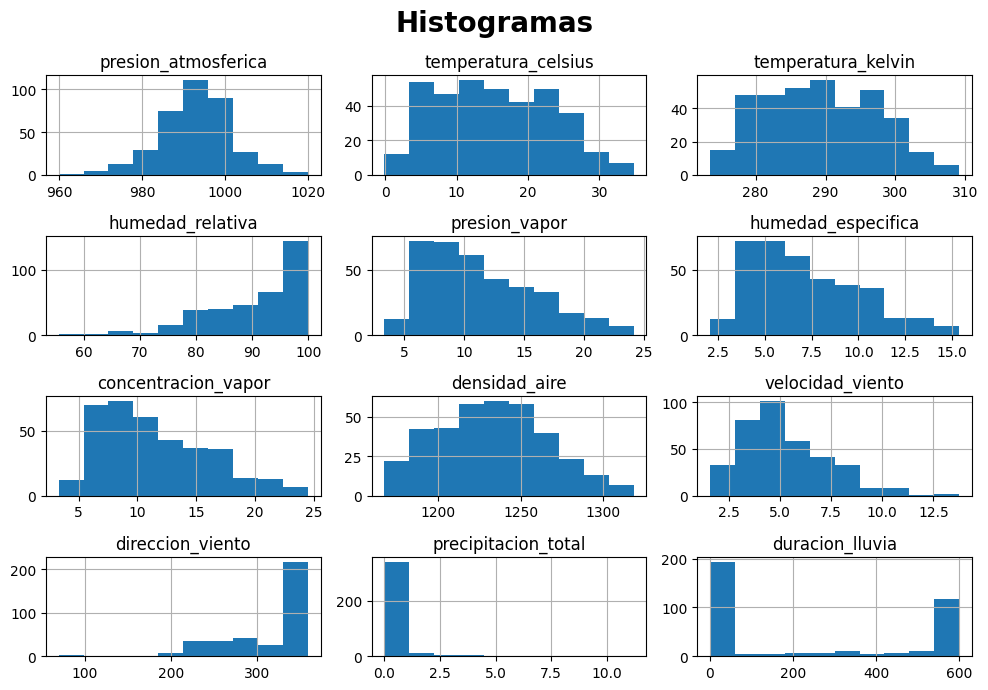

In [25]:
# 7.1
fig = indicadores_diarios.hist(figsize=(10, 7))
plt.suptitle('Histogramas', fontsize = 20, fontweight = 'bold')
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [26]:
columns_to_keep = ['humedad_relativa', 'temperatura_celsius', 'velocidad_viento']
map_mes = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

# La fecha pasa al índice del dataframe diario
indicadores_diarios = indicadores_diarios.set_index('medicion_fecha').sort_index()

# 8.1
indicadores_diarios['mes'] = pd.to_datetime(indicadores_diarios.index).month

# 8.2
indicadores_mensuales = (
    indicadores_diarios.groupby('mes')[columns_to_keep]
    .mean()
    .sort_index()
)

indicadores_mensuales.index = indicadores_mensuales.index.map(map_mes)
indicadores_mensuales

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
January,89.776129,6.821290,5.031935
February,85.719655,8.962414,7.489655
March,85.372903,9.683871,6.421290
April,80.938667,16.879667,4.997000
May,87.464839,17.135484,4.865806
June,94.256000,22.212000,5.296667
July,85.959355,24.336129,4.830323
August,92.002581,26.097742,5.040323
September,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [27]:
# 9.1
indicadores_mensuales_pt = indicadores_diarios.pivot_table(
    index = 'mes',
    values = columns_to_keep,
    aggfunc = 'mean'
)
indicadores_mensuales_pt.index = indicadores_mensuales_pt.index.map(map_mes)

print('¿Mismo resultado que con groupby()?:', indicadores_mensuales_pt[columns_to_keep].equals(indicadores_mensuales))

# 9.2
indicadores_mensuales_pt['indice_calor'] = (
    indicadores_mensuales_pt['temperatura_celsius']
    + 0.33 * indicadores_mensuales_pt['humedad_relativa']
    - 0.7 * indicadores_mensuales_pt['velocidad_viento']
    - 4
)
indicadores_mensuales_pt

¿Mismo resultado que con groupby()?: True


,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
January,89.776129,6.821290,5.031935,28.925058
February,85.719655,8.962414,7.489655,28.007141
March,85.372903,9.683871,6.421290,29.362026
April,80.938667,16.879667,4.997000,36.091527
May,87.464839,17.135484,4.865806,38.592816
June,94.256000,22.212000,5.296667,45.608813
July,85.959355,24.336129,4.830323,45.321490
August,92.002581,26.097742,5.040323,48.930368
September,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [28]:
# 10.1 melt(): el índice debe convertirse en columna para usarlo como identificador
largo_melt = indicadores_mensuales_pt.reset_index().melt(
    id_vars = 'mes',
    var_name = 'indicador',
    value_name = 'valor'
)
print('melt() ->', type(largo_melt).__name__, largo_melt.shape)
largo_melt.head(15)

melt() -> DataFrame (48, 3)


,mes,indicador,valor
0,January,humedad_relativa,89.776129
1,February,humedad_relativa,85.719655
2,March,humedad_relativa,85.372903
3,April,humedad_relativa,80.938667
4,May,humedad_relativa,87.464839
5,June,humedad_relativa,94.256000
6,July,humedad_relativa,85.959355
7,August,humedad_relativa,92.002581
8,September,humedad_relativa,97.570000
9,October,humedad_relativa,96.950645


In [29]:
# 10.2 stack(): las columnas pasan al nivel más interno del índice
largo_stack = indicadores_mensuales_pt.stack()
print('stack() ->', type(largo_stack).__name__, largo_stack.shape)
largo_stack.head(15)

stack() -> Series (48,)


mes                          
January   humedad_relativa       89.776129
          temperatura_celsius     6.821290
          velocidad_viento        5.031935
          indice_calor           28.925058
February  humedad_relativa       85.719655
          temperatura_celsius     8.962414
          velocidad_viento        7.489655
          indice_calor           28.007141
March     humedad_relativa       85.372903
          temperatura_celsius     9.683871
          velocidad_viento        6.421290
          indice_calor           29.362026
April     humedad_relativa       80.938667
          temperatura_celsius    16.879667
          velocidad_viento        4.997000
dtype: float64

> **Diferencias entre `melt()` y `stack()`:**
>
> | | `melt()` | `stack()` |
> |---|---|---|
> | **Resultado** | `DataFrame` (48 × 3) con columnas `mes`, `indicador`, `valor` | `Series` (48 valores) con un `MultiIndex` (`mes`, indicador) |
> | **Control** | Por parámetros se eligen las columnas identificadoras (`id_vars`), las que se "derriten" (`value_vars`) y los nombres (`var_name`, `value_name`) | No tiene esos parámetros: siempre mueve el nivel **más interno de las columnas** al nivel más interno del índice |
> | **Índice** | Lo ignora; para conservar `mes` hubo que pasarlo a columna con `reset_index()`. Genera un índice nuevo 0…47 | Conserva el índice original (`mes`) y le agrega un nivel |
> | **Orden** | Agrupa por variable: primero los 12 meses de humedad, luego los de temperatura, etc. | Agrupa por fila: para cada mes aparecen sus 4 indicadores seguidos |
>
> En resumen, `melt()` es más explícito y deja un dataframe "plano" listo para graficar o exportar. `stack()` es una operación de reestructuración de índices: es más rápida de escribir, pero depende de cómo estén definidos el índice y las columnas. Su inversa es `unstack()`.

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---